In [45]:
# importing labraries to perform.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 

## 🔵 STEP 1 — Data Loading & Basic Check's

In [46]:
df=pd.read_csv('ecommerce_customer_churn_dataset.csv') # loading Data Set.

In [47]:
df.shape # it show's the shape of data like col,row.

(50000, 25)

In [48]:
df.head(5) # basic understand about data 

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [49]:
df.columns # knowing colun=mns in data se

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [50]:
df.info() # basic checks.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [51]:
df.isnull().sum() # finding null values.

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

## 

## 🔵 STEP 2 — Data Cleaing

In [52]:
# filling null vales by using lambda function and median.
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Fill ALL null values at once using lambda
df[numeric_cols] = df[numeric_cols].apply(lambda col: col.fillna(col.median()))

print(f"Missing values remaining: {df.isnull().sum().sum()}")

Missing values remaining: 0


In [53]:
df.isnull().sum() # checking againg the null vales got filled or not.

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
dtype: int64

In [54]:
df.duplicated().sum() # checking Duplicates values.

np.int64(0)

In [55]:
df['Age'] = df['Age'].clip(upper=100) #Age above 100 is impossible — cap at 100

In [56]:
df['Total_Purchases'] = df['Total_Purchases'].clip(lower=0) # Negative purchases are invalid — set to 0

In [57]:
#Cart Abandonment Rate cannot exceed 100%
df['Cart_Abandonment_Rate'] = df['Cart_Abandonment_Rate'].clip(upper=100)

In [58]:
# Age should be whole number not decimal
df['Age'] = df['Age'].astype(int)

In [59]:
# checking again everything.
print(f"Rows               : {df.shape[0]}")
print(f"Columns            : {df.shape[1]}")
print(f"Missing Values     : {df.isnull().sum().sum()}")
print(f"Duplicates         : {df.duplicated().sum()}")
print(f"Age max            : {df['Age'].max()}")
print(f"Min Total_Purchases: {df['Total_Purchases'].min()}")
print(f"Max Cart Rate      : {df['Cart_Abandonment_Rate'].max()}%")

Rows               : 50000
Columns            : 25
Missing Values     : 0
Duplicates         : 0
Age max            : 100
Min Total_Purchases: 0.0
Max Cart Rate      : 100.0%


In [60]:
df.to_csv("ecommerce_cleaned.csv", index=False) # saving data set as new one

## 

## 🔵 STEP 3 — Exploratory Data Analysis (EDA)

### 📌 Task 1 — Customer Analysis

Total Customers: 50000
Average Age: 37.8
Youngest: 5
Oldest: 100

Gender Breakdown:
Gender
Female    25116
Male      23947
Other       937
Name: count, dtype: int64

Avg Membership Years: 3.0

Signups by Quarter:
Signup_Quarter
Q1    12453
Q2    12521
Q3    12558
Q4    12468
Name: count, dtype: int64


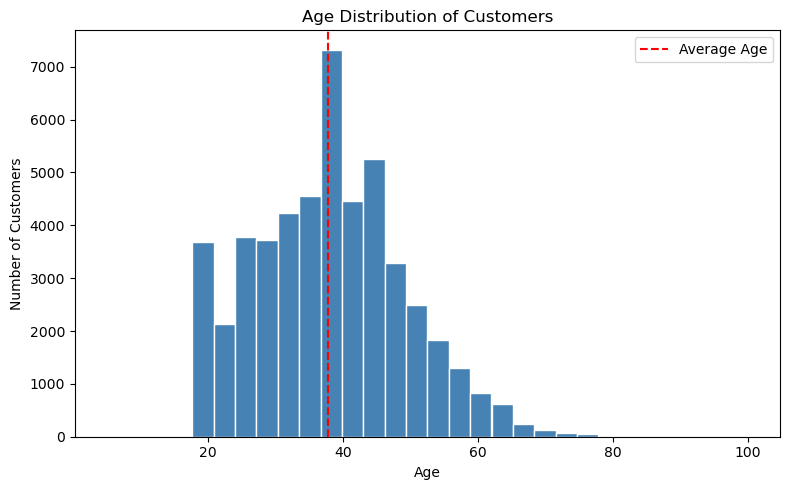

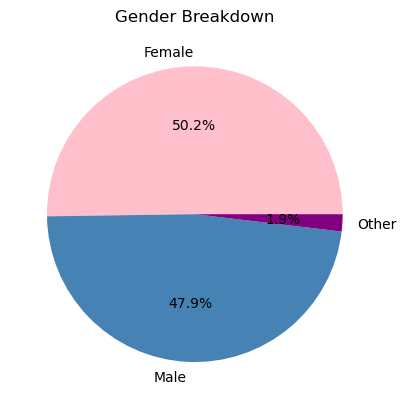

In [61]:
#Load the cleaned dataset
df = pd.read_csv("ecommerce_cleaned.csv")

# ---- 1. Basic customer info ----
print("Total Customers:", len(df))
print("Average Age:", df['Age'].mean().round(1))
print("Youngest:", df['Age'].min())
print("Oldest:", df['Age'].max())

# ---- 2. Gender count ----
print("\nGender Breakdown:")
print(df['Gender'].value_counts())

# ---- 3. Membership years ----
print("\nAvg Membership Years:", df['Membership_Years'].mean().round(1))

# ---- 4. Signup Quarter count ----
print("\nSignups by Quarter:")
print(df['Signup_Quarter'].value_counts().sort_index())

# ---- 5. Age Distribution Chart ----
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Average Age')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

# ---- 6. Gender Pie Chart ----
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['pink','steelblue','purple'])
plt.title('Gender Breakdown')
plt.ylabel('')
plt.show()

### 📌 Task 2 — Revenue Analysis

Total Revenue (Lifetime Value): 72031314.6
Average Revenue per Customer : 1440.63
Highest Revenue Customer      : 8987.24
Lowest Revenue Customer       : 0.0

Avg Order Value : 123.12
Max Order Value : 9666.38

Avg Purchases per Customer  : 13.1
Max Purchases by one Customer: 129.0

Total Revenue by Country:
Country
USA          24962102.40
UK           10824239.30
Canada        8596050.63
Germany       7129803.94
Australia     5860688.08
France        5825001.88
India         5120925.06
Japan         3712503.31
Name: Lifetime_Value, dtype: float64


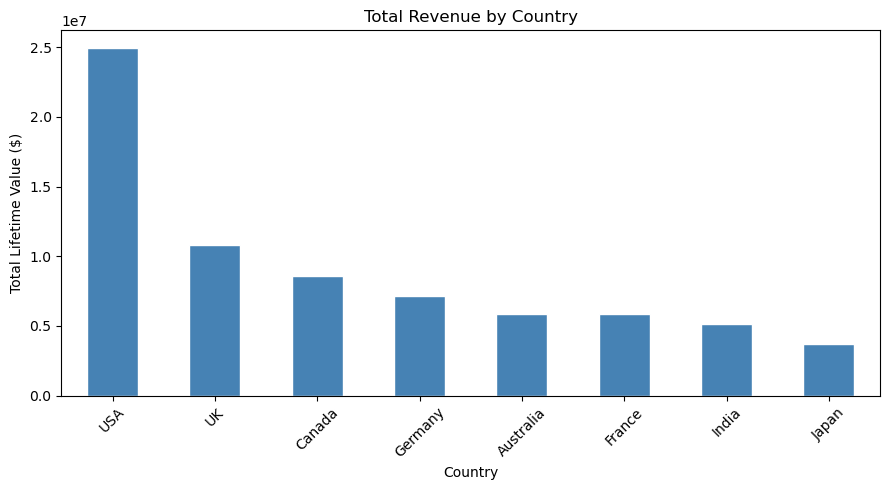

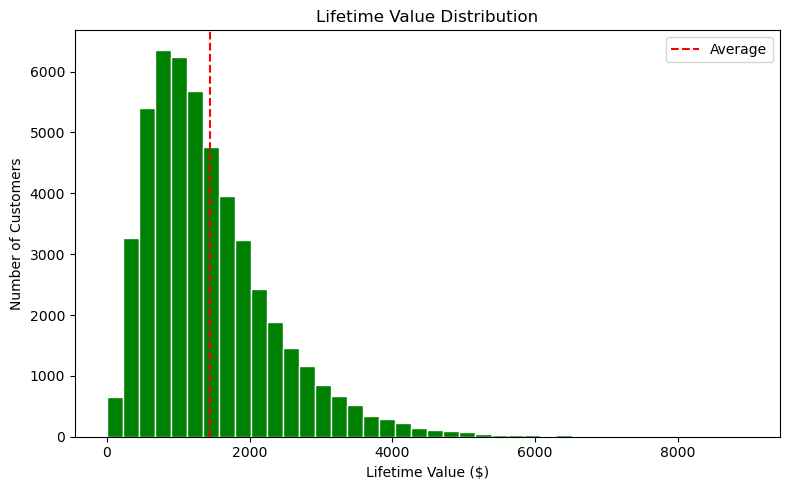

In [62]:
# ---- 1. Basic Revenue Numbers ----
print("Total Revenue (Lifetime Value):", round(df['Lifetime_Value'].sum(), 2))
print("Average Revenue per Customer :", round(df['Lifetime_Value'].mean(), 2))
print("Highest Revenue Customer      :", round(df['Lifetime_Value'].max(), 2))
print("Lowest Revenue Customer       :", round(df['Lifetime_Value'].min(), 2))

# ---- 2. Average Order Value ----
print("\nAvg Order Value :", round(df['Average_Order_Value'].mean(), 2))
print("Max Order Value :", round(df['Average_Order_Value'].max(), 2))

# ---- 3. Total Purchases ----
print("\nAvg Purchases per Customer  :", round(df['Total_Purchases'].mean(), 1))
print("Max Purchases by one Customer:", round(df['Total_Purchases'].max(), 0))

# ---- 4. Revenue by Country ----
print("\nTotal Revenue by Country:")
country_revenue = df.groupby('Country')['Lifetime_Value'].sum().sort_values(ascending=False)
print(country_revenue.round(2))

# ---- 5. Bar Chart — Revenue by Country ----
plt.figure(figsize=(9, 5))
country_revenue.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Total Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Total Lifetime Value ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- 6. Histogram — Lifetime Value Distribution ----
plt.figure(figsize=(8, 5))
plt.hist(df['Lifetime_Value'], bins=40, color='green', edgecolor='white')
plt.axvline(df['Lifetime_Value'].mean(), color='red', linestyle='--', label='Average')
plt.title('Lifetime Value Distribution')
plt.xlabel('Lifetime Value ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

### 📌 Task 3 — Churn Analysis

Total Customers      : 50000
Total Churned        : 14450
Total Not Churned    : 35550
Churn Rate           : 28.9 %

Average values — Churned vs Not Churned:
           Age  Login_Frequency  Session_Duration_Avg  Total_Purchases  \
Churned                                                                  
0        38.52            12.64                 29.07            13.83   
1        35.97             9.12                 23.99            11.35   

         Cart_Abandonment_Rate  Email_Open_Rate  
Churned                                          
0                        54.18            22.79  
1                        64.17            16.16  

Churn Rate by Gender:
Gender
Female    28.97
Male      28.73
Other     31.27
Name: Churned, dtype: float64


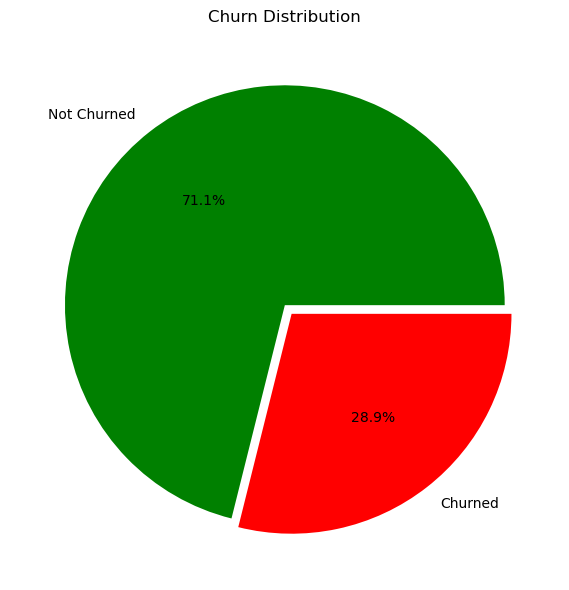

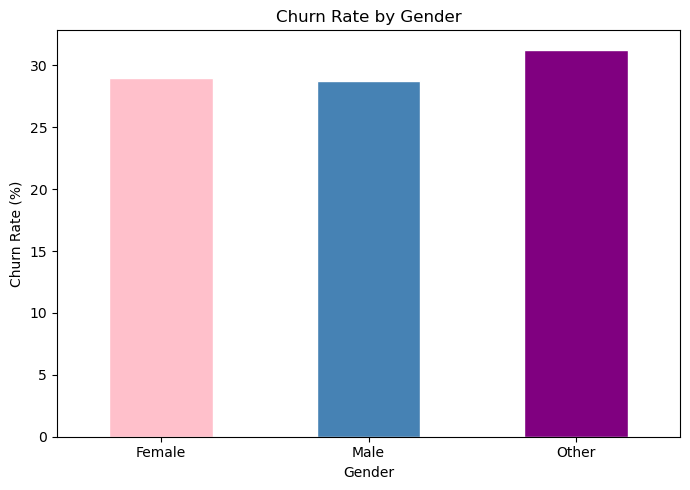

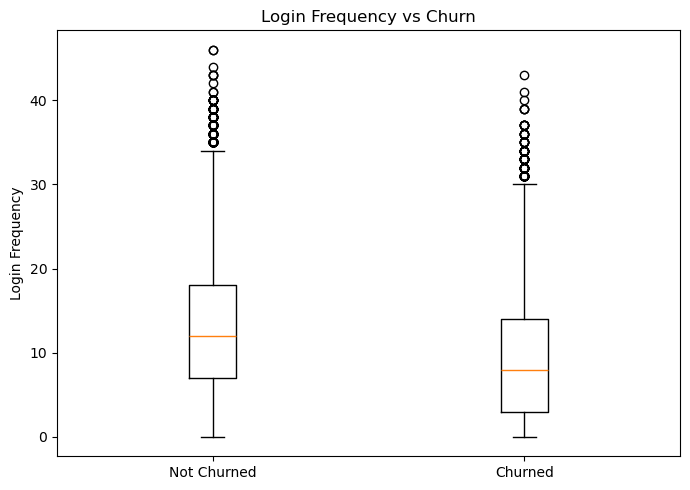

In [63]:
# ---- 1. Basic Churn Numbers ----
print("Total Customers      :", len(df))
print("Total Churned        :", df['Churned'].sum())
print("Total Not Churned    :", len(df) - df['Churned'].sum())
print("Churn Rate           :", round(df['Churned'].mean() * 100, 2), "%")

# ---- 2. Churned vs Not Churned Averages ----
print("\nAverage values — Churned vs Not Churned:")
cols = ['Age', 'Login_Frequency', 'Session_Duration_Avg',
        'Total_Purchases', 'Cart_Abandonment_Rate', 'Email_Open_Rate']

print(df.groupby('Churned')[cols].mean().round(2))

# ---- 3. Churn by Gender ----
print("\nChurn Rate by Gender:")
gender_churn = df.groupby('Gender')['Churned'].mean() * 100
print(gender_churn.round(2))

# ---- 4. Pie Chart — Churn Distribution ----
plt.figure(figsize=(6, 6))
df['Churned'].value_counts().plot(kind='pie',
    labels=['Not Churned', 'Churned'],
    autopct='%1.1f%%',
    colors=['green', 'red'],
    explode=(0, 0.05))
plt.title('Churn Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

# ---- 5. Bar Chart — Churn Rate by Gender ----
plt.figure(figsize=(7, 5))
gender_churn.plot(kind='bar', color=['pink', 'steelblue', 'purple'], edgecolor='white')
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- 6. Box Plot — Login Frequency vs Churn ----
churned     = df[df['Churned'] == 1]['Login_Frequency']
not_churned = df[df['Churned'] == 0]['Login_Frequency']

plt.figure(figsize=(7, 5))
plt.boxplot([not_churned, churned], tick_labels=['Not Churned', 'Churned'])
plt.title('Login Frequency vs Churn')
plt.ylabel('Login Frequency')
plt.tight_layout()
plt.show()

### 📌 Task 4 — Country Analysis

Total Customers by Country:
Country
USA          17384
UK            7534
Canada        6023
Germany       4925
Australia     4061
France        4013
India         3512
Japan         2548
Name: count, dtype: int64

Total Revenue by Country:
Country
USA          24962102.40
UK           10824239.30
Canada        8596050.63
Germany       7129803.94
Australia     5860688.08
France        5825001.88
India         5120925.06
Japan         3712503.31
Name: Lifetime_Value, dtype: float64

Avg Order Value by Country:
Country
UK           125.94
France       125.58
Japan        123.40
Canada       123.22
USA          122.86
Germany      121.54
India        121.53
Australia    119.48
Name: Average_Order_Value, dtype: float64

Churn Rate by Country (%):
Country
Australia    29.89
Canada       29.35
USA          29.08
India        29.01
Germany      28.83
UK           28.79
Japan        27.83
France       27.29
Name: Churned, dtype: float64


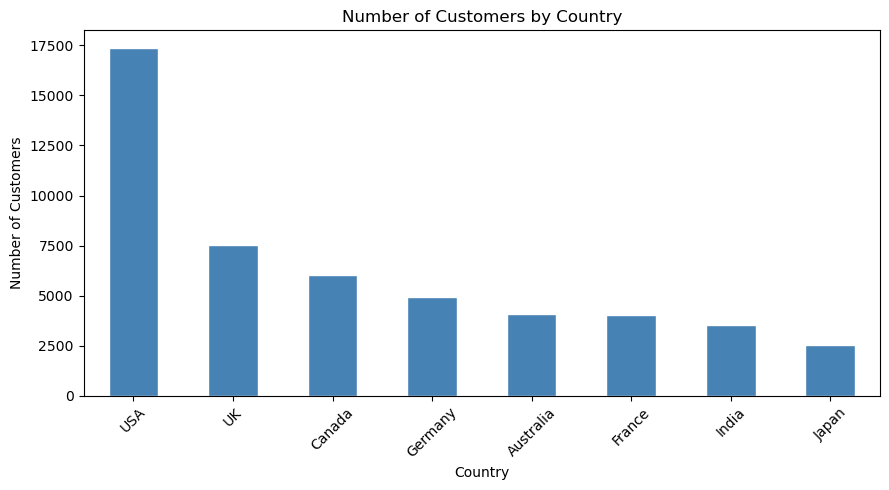

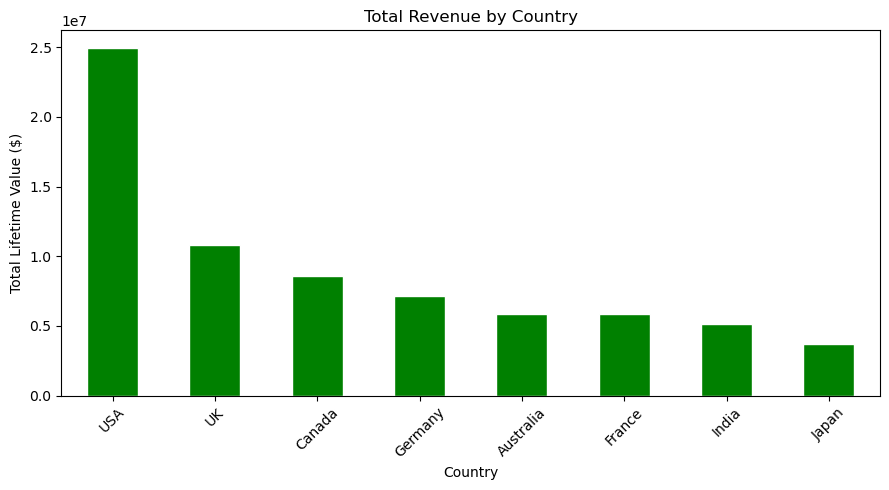

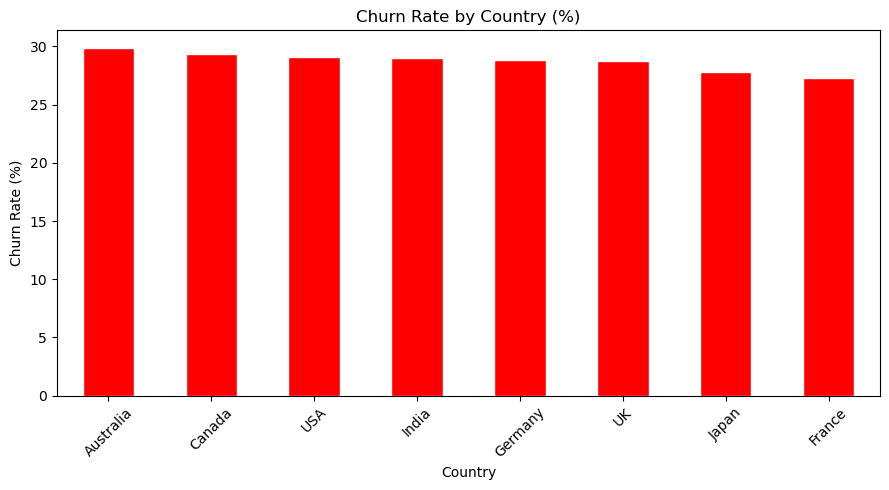

In [64]:
# ---- 1. Customer Count by Country ----
print("Total Customers by Country:")
print(df['Country'].value_counts())

# ---- 2. Revenue by Country ----
print("\nTotal Revenue by Country:")
country_revenue = df.groupby('Country')['Lifetime_Value'].sum().sort_values(ascending=False)
print(country_revenue.round(2))

# ---- 3. Average Order Value by Country ----
print("\nAvg Order Value by Country:")
country_aov = df.groupby('Country')['Average_Order_Value'].mean().sort_values(ascending=False)
print(country_aov.round(2))

# ---- 4. Churn Rate by Country ----
print("\nChurn Rate by Country (%):")
country_churn = df.groupby('Country')['Churned'].mean() * 100
print(country_churn.round(2).sort_values(ascending=False))

# ---- 5. Bar Chart — Customers by Country ----
plt.figure(figsize=(9, 5))
df['Country'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Customers by Country')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- 6. Bar Chart — Revenue by Country ----
plt.figure(figsize=(9, 5))
country_revenue.plot(kind='bar', color='green', edgecolor='white')
plt.title('Total Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Total Lifetime Value ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- 7. Bar Chart — Churn Rate by Country ----
plt.figure(figsize=(9, 5))
country_churn.sort_values(ascending=False).plot(kind='bar', color='red', edgecolor='white')
plt.title('Churn Rate by Country (%)')
plt.xlabel('Country')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📌 Task 5 — Engagement Analysis

Average Login Frequency        : 11.6
Average Session Duration (min) : 27.6
Average Pages Per Session      : 8.7
Average Email Open Rate        : 20.9 %
Average Mobile App Usage       : 19.3
Average Social Media Score     : 29.2

Engagement Comparison — Churned vs Not Churned:
         Login_Frequency  Session_Duration_Avg  Pages_Per_Session  \
Churned                                                             
0                  12.64                 29.07               9.24   
1                   9.12                 23.99               7.43   

         Email_Open_Rate  Mobile_App_Usage  Social_Media_Engagement_Score  
Churned                                                                    
0                  22.79             20.50                          31.37  
1                  16.16             16.33                          23.71  

Correlation with Lifetime Value:
Login_Frequency         0.499
Session_Duration_Avg    0.542
Pages_Per_Session       0.515
Email_Open_Rate  

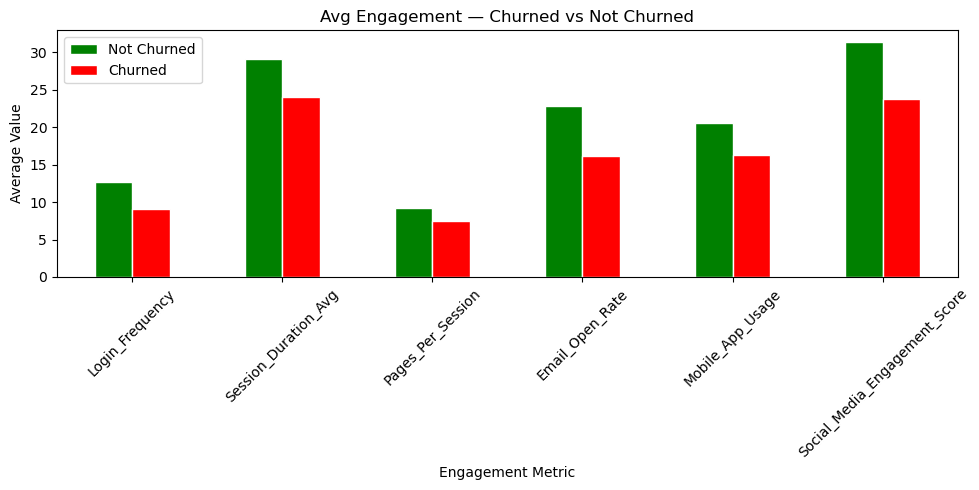

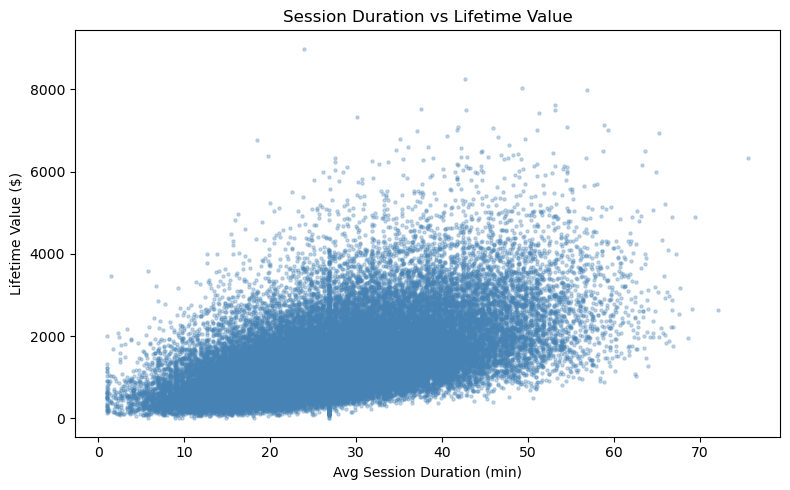

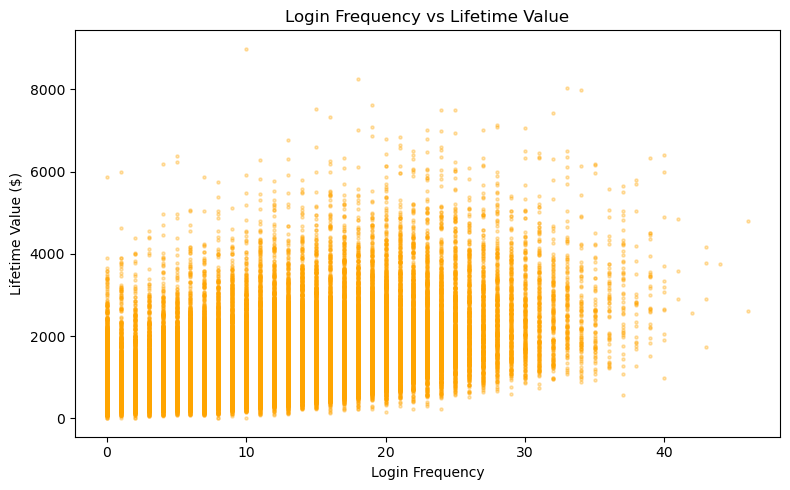

In [65]:
# ---- 1. Basic Engagement Numbers ----
print("Average Login Frequency        :", round(df['Login_Frequency'].mean(), 1))
print("Average Session Duration (min) :", round(df['Session_Duration_Avg'].mean(), 1))
print("Average Pages Per Session      :", round(df['Pages_Per_Session'].mean(), 1))
print("Average Email Open Rate        :", round(df['Email_Open_Rate'].mean(), 1), "%")
print("Average Mobile App Usage       :", round(df['Mobile_App_Usage'].mean(), 1))
print("Average Social Media Score     :", round(df['Social_Media_Engagement_Score'].mean(), 1))

# ---- 2. Engagement — Churned vs Not Churned ----
print("\nEngagement Comparison — Churned vs Not Churned:")
eng_cols = ['Login_Frequency', 'Session_Duration_Avg',
            'Pages_Per_Session', 'Email_Open_Rate',
            'Mobile_App_Usage', 'Social_Media_Engagement_Score']

print(df.groupby('Churned')[eng_cols].mean().round(2))

# ---- 3. Correlation — Engagement vs Lifetime Value ----
print("\nCorrelation with Lifetime Value:")
corr_cols = ['Login_Frequency', 'Session_Duration_Avg',
             'Pages_Per_Session', 'Email_Open_Rate', 'Mobile_App_Usage']
print(df[corr_cols + ['Lifetime_Value']].corr()['Lifetime_Value'].drop('Lifetime_Value').round(3))

# ---- 4. Bar Chart — Avg Engagement Churned vs Not Churned ----
eng_data = df.groupby('Churned')[eng_cols].mean()
eng_data.index = ['Not Churned', 'Churned']

eng_data.T.plot(kind='bar', figsize=(10, 5), color=['green', 'red'], edgecolor='white')
plt.title('Avg Engagement — Churned vs Not Churned')
plt.xlabel('Engagement Metric')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(['Not Churned', 'Churned'])
plt.tight_layout()
plt.show()

# ---- 5. Scatter Plot — Session Duration vs Lifetime Value ----
plt.figure(figsize=(8, 5))
plt.scatter(df['Session_Duration_Avg'], df['Lifetime_Value'],
            alpha=0.3, color='steelblue', s=5)
plt.title('Session Duration vs Lifetime Value')
plt.xlabel('Avg Session Duration (min)')
plt.ylabel('Lifetime Value ($)')
plt.tight_layout()
plt.show()

# ---- 6. Scatter Plot — Login Frequency vs Lifetime Value ----
plt.figure(figsize=(8, 5))
plt.scatter(df['Login_Frequency'], df['Lifetime_Value'],
            alpha=0.3, color='orange', s=5)
plt.title('Login Frequency vs Lifetime Value')
plt.xlabel('Login Frequency')
plt.ylabel('Lifetime Value ($)')
plt.tight_layout()
plt.show()

## 

## 🟠 STEP 4 — Business Problem Analysis

### ❓Question 1 — Why are customers churning?

             Login_Frequency  Session_Duration_Avg  Cart_Abandonment_Rate  \
Not Churned            12.64                 29.07                  54.18   
Churned                 9.12                 23.99                  64.17   

             Customer_Service_Calls  Email_Open_Rate  Total_Purchases  
Not Churned                    5.18            22.79            13.83  
Churned                        6.90            16.16            11.35  


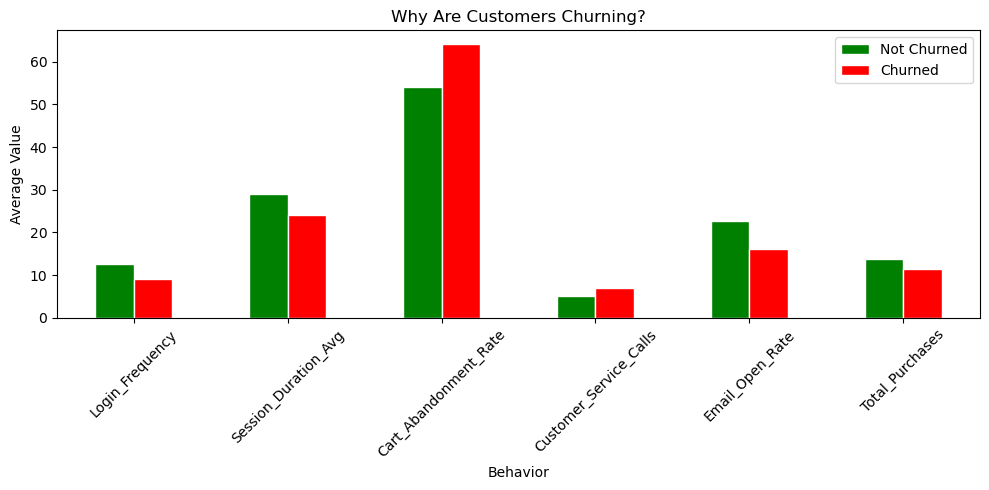

In [67]:

# ---- Compare key behaviors: Churned vs Not Churned ----
cols = ['Login_Frequency', 'Session_Duration_Avg',
        'Cart_Abandonment_Rate', 'Customer_Service_Calls',
        'Email_Open_Rate', 'Total_Purchases']

comparison = df.groupby('Churned')[cols].mean().round(2)
comparison.index = ['Not Churned', 'Churned']
print(comparison)

# ---- Bar Chart ----
comparison.T.plot(kind='bar', color=['green', 'red'], edgecolor='white', figsize=(10, 5))
plt.title('Why Are Customers Churning?')
plt.xlabel('Behavior')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(['Not Churned', 'Churned'])
plt.tight_layout()
plt.show()

### ❓Question 2 — Which customers generate the highest revenue and lifetime value?

Top 10 Highest Lifetime Value Customers:
       Age  Gender Country  Lifetime_Value  Total_Purchases  \
43141   41    Male     USA         8987.24             28.0   
40771   26  Female  Canada         8243.53             24.0   
9361    54    Male     USA         8023.20             28.0   
37041   49    Male   India         7990.07             33.0   
31921   37    Male   India         7631.01             23.0   
26887   36  Female     USA         7533.68             20.0   
48071   24    Male  Canada         7507.81             26.0   
28543   39  Female      UK         7488.19             20.0   
23780   35  Female  France         7429.18             23.0   
28949   55  Female     USA         7324.28             25.0   

       Average_Order_Value  
43141               278.92  
40771               335.39  
9361                239.20  
37041               245.17  
31921               282.05  
26887               397.85  
48071               262.04  
28543               346.20  
2378

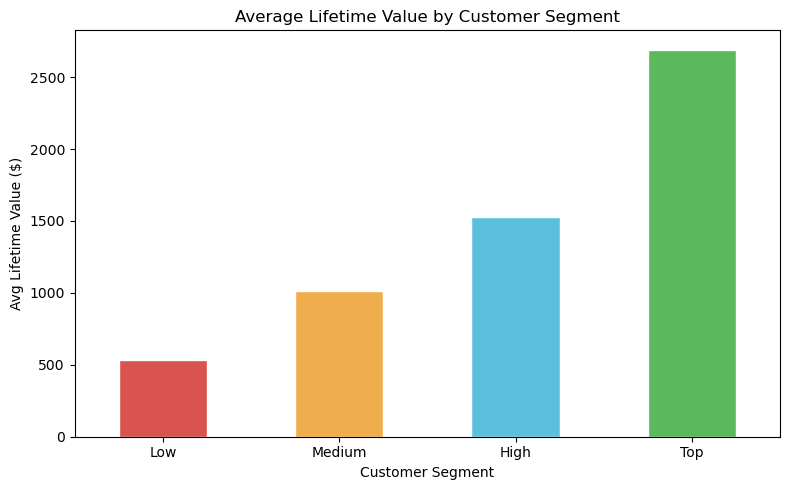

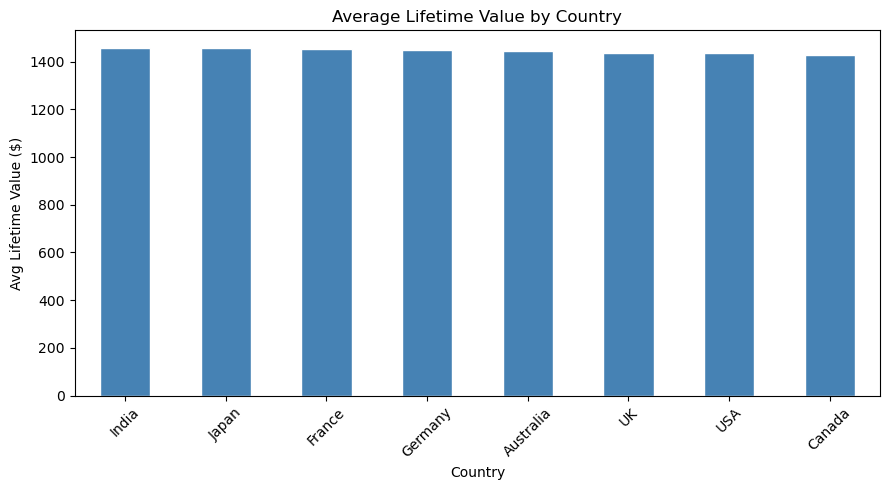

In [69]:

# ---- 1. Top 10 highest value customers ----
print("Top 10 Highest Lifetime Value Customers:")
top10 = df[['Age', 'Gender', 'Country', 'Lifetime_Value', 'Total_Purchases',
            'Average_Order_Value']].sort_values('Lifetime_Value', ascending=False).head(10)
print(top10)

# ---- 2. Segment customers into value groups ----
# We split all customers into 4 equal groups based on lifetime value
df['Value_Segment'] = pd.qcut(df['Lifetime_Value'], q=4,
                               labels=['Low', 'Medium', 'High', 'Top'])

print("\nCustomer Count by Value Segment:")
print(df['Value_Segment'].value_counts().sort_index())

print("\nAverage Stats by Value Segment:")
seg_cols = ['Lifetime_Value', 'Total_Purchases', 'Average_Order_Value',
            'Login_Frequency', 'Session_Duration_Avg']
print(df.groupby('Value_Segment', observed=True)[seg_cols].mean().round(2))
# ---- 3. Bar Chart — Avg Lifetime Value by Segment ----
seg_revenue = df.groupby('Value_Segment', observed=True)['Lifetime_Value'].mean()

plt.figure(figsize=(8, 5))
seg_revenue.plot(kind='bar', color=['#d9534f','#f0ad4e','#5bc0de','#5cb85c'], edgecolor='white')
plt.title('Average Lifetime Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Avg Lifetime Value ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- 4. Bar Chart — Avg Lifetime Value by Country ----
country_ltv = df.groupby('Country')['Lifetime_Value'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
country_ltv.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Lifetime Value by Country')
plt.xlabel('Country')
plt.ylabel('Avg Lifetime Value ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ❓Question 3 — What factors increase Customer Lifetime Value?

Correlation with Lifetime Value:
Total_Purchases                  0.624
Session_Duration_Avg             0.542
Pages_Per_Session                0.515
Mobile_App_Usage                 0.501
Login_Frequency                  0.499
Email_Open_Rate                  0.460
Social_Media_Engagement_Score    0.431
Average_Order_Value              0.152
Membership_Years                 0.004
Discount_Usage_Rate              0.001
Name: Lifetime_Value, dtype: float64

Avg Lifetime Value by Membership Year Group:
Membership_Group
0-2yr     1441.15
2-4yr     1438.10
4-6yr     1429.64
6-8yr     1477.36
8-10yr    1449.16
Name: Lifetime_Value, dtype: float64

Avg Lifetime Value by Purchase Group:
Purchase_Group
0-5       455.21
5-10      923.24
10-20    1637.99
20-50    2571.66
50+      1445.28
Name: Lifetime_Value, dtype: float64


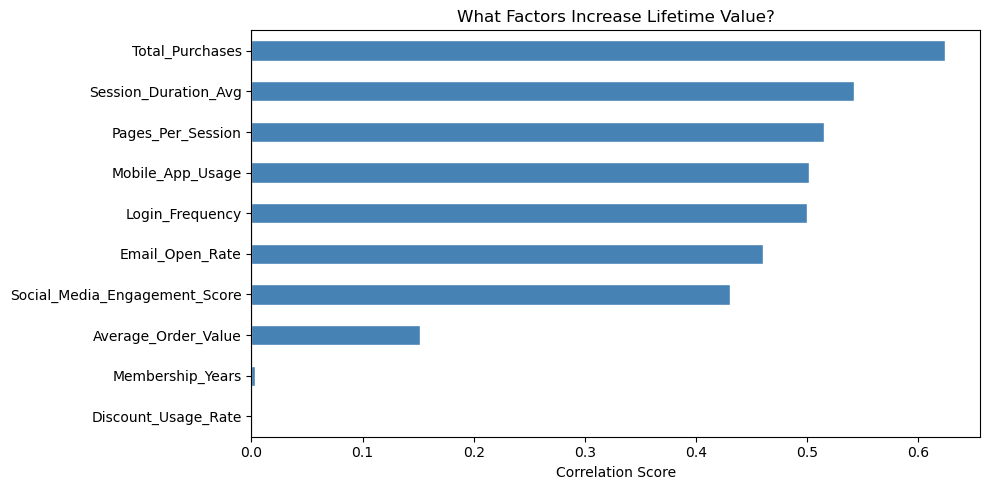

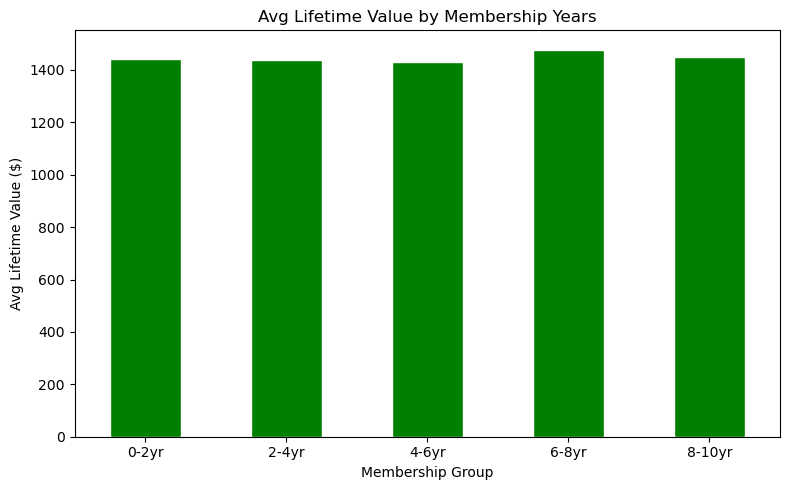

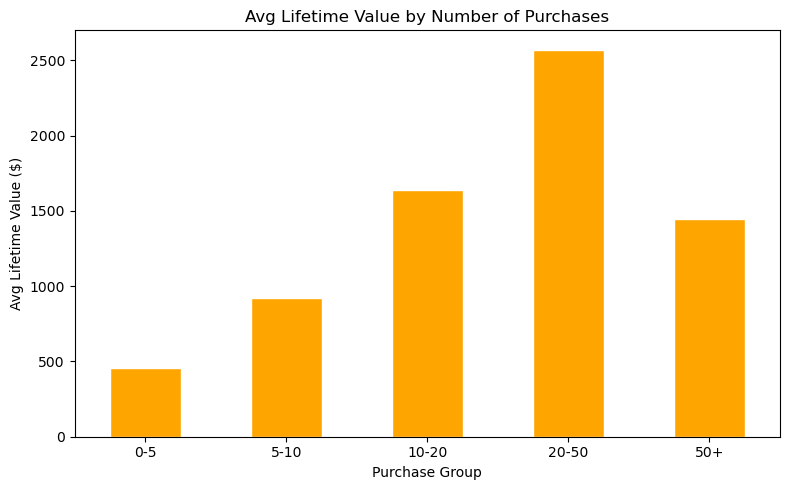

In [70]:
# ---- 1. Correlation — what is related to Lifetime Value ----
print("Correlation with Lifetime Value:")
cols = ['Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
        'Total_Purchases', 'Average_Order_Value', 'Email_Open_Rate',
        'Mobile_App_Usage', 'Discount_Usage_Rate', 'Membership_Years',
        'Social_Media_Engagement_Score']

corr = df[cols + ['Lifetime_Value']].corr()['Lifetime_Value'].drop('Lifetime_Value')
print(corr.sort_values(ascending=False).round(3))

# ---- 2. Membership Years vs Lifetime Value ----
print("\nAvg Lifetime Value by Membership Year Group:")
df['Membership_Group'] = pd.cut(df['Membership_Years'],
                                 bins=[0, 2, 4, 6, 8, 10],
                                 labels=['0-2yr', '2-4yr', '4-6yr', '6-8yr', '8-10yr'])

mem_ltv = df.groupby('Membership_Group', observed=True)['Lifetime_Value'].mean()
print(mem_ltv.round(2))

# ---- 3. Total Purchases vs Lifetime Value ----
print("\nAvg Lifetime Value by Purchase Group:")
df['Purchase_Group'] = pd.cut(df['Total_Purchases'],
                               bins=[0, 5, 10, 20, 50, 130],
                               labels=['0-5', '5-10', '10-20', '20-50', '50+'])

pur_ltv = df.groupby('Purchase_Group', observed=True)['Lifetime_Value'].mean()
print(pur_ltv.round(2))

# ---- 4. Bar Chart — Correlation with Lifetime Value ----
plt.figure(figsize=(10, 5))
corr.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('What Factors Increase Lifetime Value?')
plt.xlabel('Correlation Score')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# ---- 5. Bar Chart — Membership Years vs Lifetime Value ----
plt.figure(figsize=(8, 5))
mem_ltv.plot(kind='bar', color='green', edgecolor='white')
plt.title('Avg Lifetime Value by Membership Years')
plt.xlabel('Membership Group')
plt.ylabel('Avg Lifetime Value ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- 6. Bar Chart — Total Purchases vs Lifetime Value ----
plt.figure(figsize=(8, 5))
pur_ltv.plot(kind='bar', color='orange', edgecolor='white')
plt.title('Avg Lifetime Value by Number of Purchases')
plt.xlabel('Purchase Group')
plt.ylabel('Avg Lifetime Value ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### ❓Question 4 — Which customers need retention campaigns?

=== AT-RISK CUSTOMERS ===
Total At-Risk Customers : 23744
% of all customers      : 47.49%

Already Churned (from at-risk) : 9663
Still Active (from at-risk)    : 14081

At-Risk Customers by Country:
Country
USA          8318
UK           3576
Canada       2902
Germany      2314
Australia    1934
France       1892
India        1652
Japan        1156
Name: count, dtype: int64

At-Risk Customers by Gender:
Gender
Female    11923
Male      11381
Other       440
Name: count, dtype: int64

Avg Behavior of At-Risk Customers:
Login_Frequency              6.76
Cart_Abandonment_Rate       67.47
Customer_Service_Calls       6.98
Email_Open_Rate             12.02
Total_Purchases              9.57
Lifetime_Value            1048.39
dtype: float64


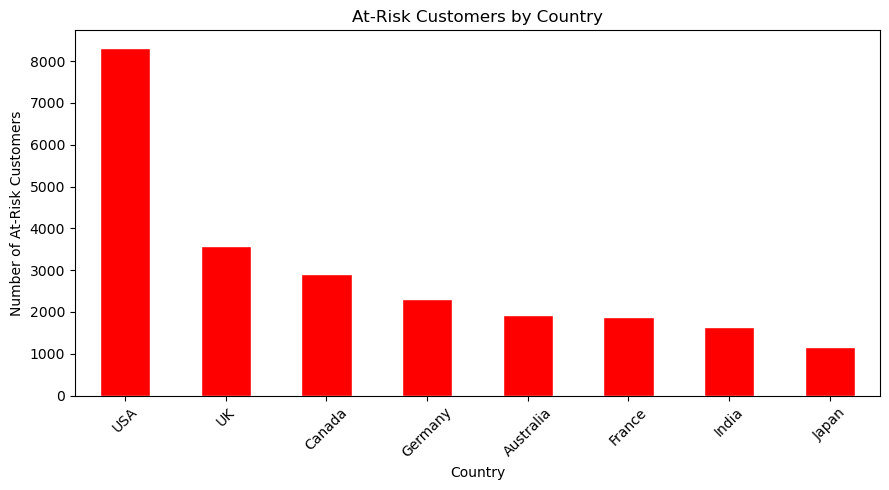

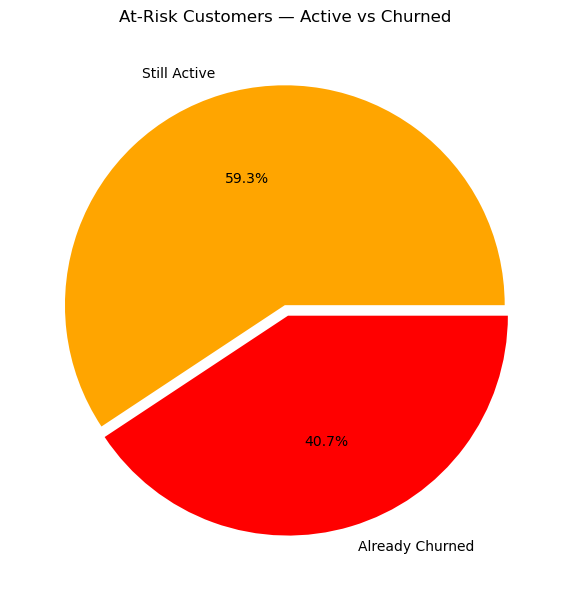

In [71]:
# ---- 1. Define At-Risk Customers ----
# A customer is at risk if they show these warning signs:
# - High cart abandonment (above 70%)
# - Low login frequency (below 5)
# - Many customer service calls (above 8)
# - Low email open rate (below 10%)

at_risk = df[
    (df['Cart_Abandonment_Rate'] > 70) |   # | means OR
    (df['Login_Frequency'] < 5)            |
    (df['Customer_Service_Calls'] > 8)     |
    (df['Email_Open_Rate'] < 10)
]

print("=== AT-RISK CUSTOMERS ===")
print(f"Total At-Risk Customers : {len(at_risk)}")
print(f"% of all customers      : {round(len(at_risk) / len(df) * 100, 2)}%")

# ---- 2. How many of at-risk already churned ----
print(f"\nAlready Churned (from at-risk) : {at_risk['Churned'].sum()}")
print(f"Still Active (from at-risk)    : {len(at_risk) - at_risk['Churned'].sum()}")

# ---- 3. At-Risk by Country ----
print("\nAt-Risk Customers by Country:")
print(at_risk['Country'].value_counts())

# ---- 4. At-Risk by Gender ----
print("\nAt-Risk Customers by Gender:")
print(at_risk['Gender'].value_counts())

# ---- 5. Average behavior of at-risk customers ----
print("\nAvg Behavior of At-Risk Customers:")
cols = ['Login_Frequency', 'Cart_Abandonment_Rate',
        'Customer_Service_Calls', 'Email_Open_Rate',
        'Total_Purchases', 'Lifetime_Value']
print(at_risk[cols].mean().round(2))

# ---- 6. Bar Chart — At-Risk by Country ----
plt.figure(figsize=(9, 5))
at_risk['Country'].value_counts().plot(kind='bar', color='red', edgecolor='white')
plt.title('At-Risk Customers by Country')
plt.xlabel('Country')
plt.ylabel('Number of At-Risk Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- 7. Pie Chart — At-Risk Already Churned vs Still Active ----
plt.figure(figsize=(6, 6))
labels = ['Still Active', 'Already Churned']
sizes  = [len(at_risk) - at_risk['Churned'].sum(), at_risk['Churned'].sum()]
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=['orange', 'red'], explode=(0, 0.05))
plt.title('At-Risk Customers — Active vs Churned')
plt.tight_layout()
plt.show()

### ❓Question 5 — Does Customer Engagement Affect Sales and Revenue?

Correlation — Engagement vs Lifetime Value:
Session_Duration_Avg             0.542
Pages_Per_Session                0.515
Mobile_App_Usage                 0.501
Login_Frequency                  0.499
Email_Open_Rate                  0.460
Social_Media_Engagement_Score    0.431
Name: Lifetime_Value, dtype: float64

Correlation — Engagement vs Total Purchases:
Session_Duration_Avg             0.641
Pages_Per_Session                0.608
Mobile_App_Usage                 0.592
Login_Frequency                  0.589
Email_Open_Rate                  0.543
Social_Media_Engagement_Score    0.511
Name: Total_Purchases, dtype: float64

Avg Revenue by Login Frequency Group:
Login_Group
Low(0-5)           995.85
Medium(5-10)      1199.66
High(10-20)       1612.73
Very High(20+)    2272.91
Name: Lifetime_Value, dtype: float64

Avg Revenue by Session Duration Group:
Session_Group
Short(0-15)        784.75
Medium(15-30)     1192.16
Long(30-50)       1941.19
Very Long(50+)    2757.07
Name: Lifetime_Va

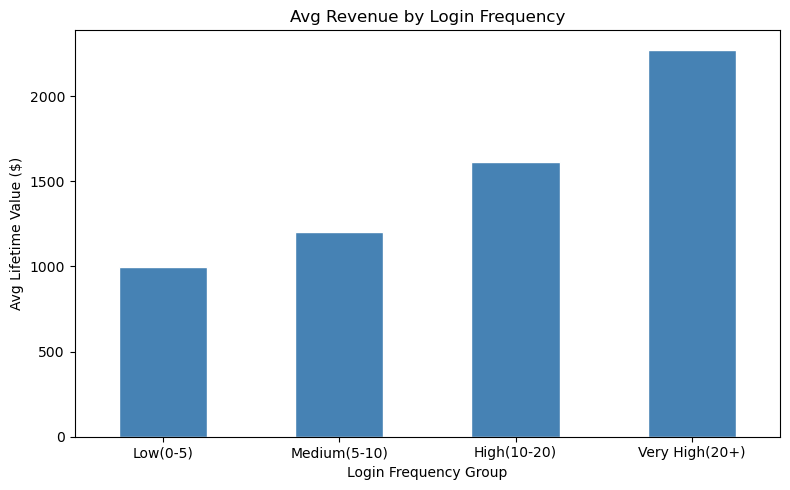

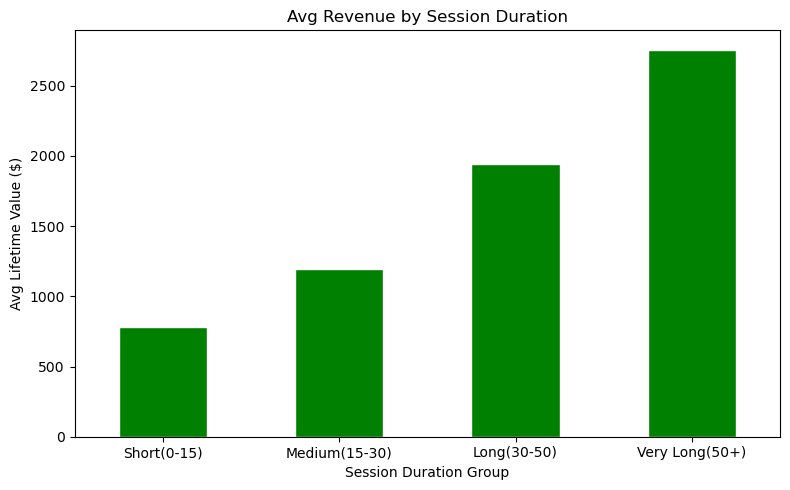

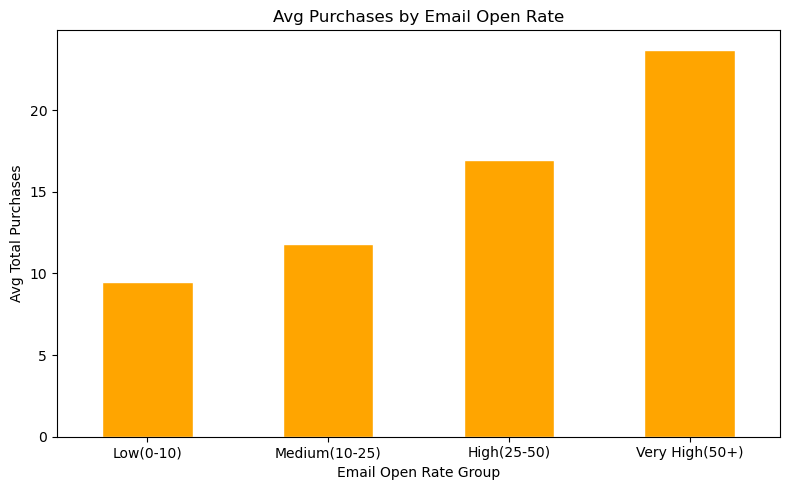

In [72]:
# ---- 1. Correlation — Engagement vs Revenue & Purchases ----
print("Correlation — Engagement vs Lifetime Value:")
eng_cols = ['Login_Frequency', 'Session_Duration_Avg',
            'Pages_Per_Session', 'Email_Open_Rate',
            'Mobile_App_Usage', 'Social_Media_Engagement_Score']

corr_ltv = df[eng_cols + ['Lifetime_Value']].corr()['Lifetime_Value'].drop('Lifetime_Value')
print(corr_ltv.sort_values(ascending=False).round(3))

print("\nCorrelation — Engagement vs Total Purchases:")
corr_pur = df[eng_cols + ['Total_Purchases']].corr()['Total_Purchases'].drop('Total_Purchases')
print(corr_pur.sort_values(ascending=False).round(3))

# ---- 2. Group by Login Frequency ----
print("\nAvg Revenue by Login Frequency Group:")
df['Login_Group'] = pd.cut(df['Login_Frequency'],
                            bins=[0, 5, 10, 20, 50],
                            labels=['Low(0-5)', 'Medium(5-10)',
                                    'High(10-20)', 'Very High(20+)'])

login_rev = df.groupby('Login_Group', observed=True)['Lifetime_Value'].mean()
print(login_rev.round(2))

# ---- 3. Group by Session Duration ----
print("\nAvg Revenue by Session Duration Group:")
df['Session_Group'] = pd.cut(df['Session_Duration_Avg'],
                              bins=[0, 15, 30, 50, 80],
                              labels=['Short(0-15)', 'Medium(15-30)',
                                      'Long(30-50)', 'Very Long(50+)'])

session_rev = df.groupby('Session_Group', observed=True)['Lifetime_Value'].mean()
print(session_rev.round(2))

# ---- 4. Bar Chart — Login Frequency vs Revenue ----
plt.figure(figsize=(8, 5))
login_rev.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Avg Revenue by Login Frequency')
plt.xlabel('Login Frequency Group')
plt.ylabel('Avg Lifetime Value ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- 5. Bar Chart — Session Duration vs Revenue ----
plt.figure(figsize=(8, 5))
session_rev.plot(kind='bar', color='green', edgecolor='white')
plt.title('Avg Revenue by Session Duration')
plt.xlabel('Session Duration Group')
plt.ylabel('Avg Lifetime Value ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- 6. Bar Chart — Email Open Rate vs Purchases ----
df['Email_Group'] = pd.cut(df['Email_Open_Rate'],
                            bins=[0, 10, 25, 50, 100],
                            labels=['Low(0-10)', 'Medium(10-25)',
                                    'High(25-50)', 'Very High(50+)'])

email_pur = df.groupby('Email_Group', observed=True)['Total_Purchases'].mean()

plt.figure(figsize=(8, 5))
email_pur.plot(kind='bar', color='orange', edgecolor='white')
plt.title('Avg Purchases by Email Open Rate')
plt.xlabel('Email Open Rate Group')
plt.ylabel('Avg Total Purchases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### ❓Question 6 — Which Countries Generate the Highest Revenue?

Total Revenue by Country:
Country
USA          24962102.40
UK           10824239.30
Canada        8596050.63
Germany       7129803.94
Australia     5860688.08
France        5825001.88
India         5120925.06
Japan         3712503.31
Name: Lifetime_Value, dtype: float64

Avg Revenue per Customer by Country:
Country
India        1458.12
Japan        1457.03
France       1451.53
Germany      1447.68
Australia    1443.16
UK           1436.72
USA          1435.92
Canada       1427.20
Name: Lifetime_Value, dtype: float64

Total Purchases by Country:
Country
USA          227523.0
UK            98766.0
Canada        78434.0
Germany       65160.0
Australia     53319.0
France        52731.0
India         46520.0
Japan         33374.0
Name: Total_Purchases, dtype: float64

Avg Order Value by Country:
Country
UK           125.94
France       125.58
Japan        123.40
Canada       123.22
USA          122.86
Germany      121.54
India        121.53
Australia    119.48
Name: Average_Order_Value, dty

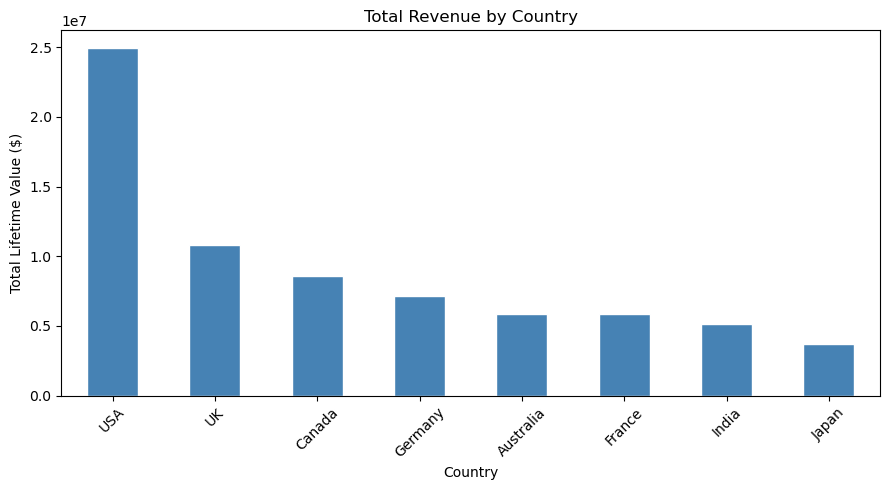

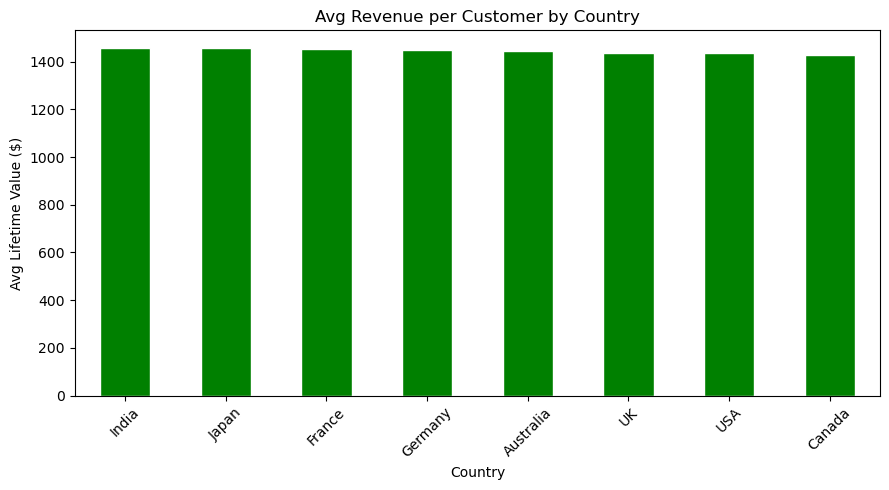

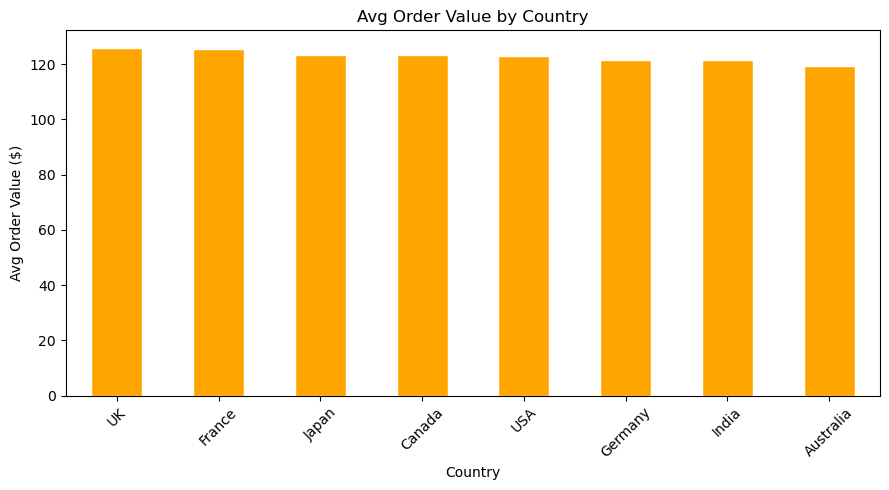

In [73]:
# ---- 1. Total Revenue by Country ----
print("Total Revenue by Country:")
total_rev = df.groupby('Country')['Lifetime_Value'].sum().sort_values(ascending=False)
print(total_rev.round(2))

# ---- 2. Average Revenue per Customer by Country ----
print("\nAvg Revenue per Customer by Country:")
avg_rev = df.groupby('Country')['Lifetime_Value'].mean().sort_values(ascending=False)
print(avg_rev.round(2))

# ---- 3. Total Purchases by Country ----
print("\nTotal Purchases by Country:")
total_pur = df.groupby('Country')['Total_Purchases'].sum().sort_values(ascending=False)
print(total_pur.round(0))

# ---- 4. Average Order Value by Country ----
print("\nAvg Order Value by Country:")
avg_aov = df.groupby('Country')['Average_Order_Value'].mean().sort_values(ascending=False)
print(avg_aov.round(2))

# ---- 5. Full Summary Table ----
print("\nFull Country Summary:")
summary = df.groupby('Country').agg(
    Total_Customers    = ('Lifetime_Value', 'count'),
    Total_Revenue      = ('Lifetime_Value', 'sum'),
    Avg_Revenue        = ('Lifetime_Value', 'mean'),
    Avg_Order_Value    = ('Average_Order_Value', 'mean'),
    Churn_Rate_pct     = ('Churned', 'mean')
).round(2)
summary['Churn_Rate_pct'] = (summary['Churn_Rate_pct'] * 100).round(2)
summary = summary.sort_values('Total_Revenue', ascending=False)
print(summary)

# ---- 6. Bar Chart — Total Revenue by Country ----
plt.figure(figsize=(9, 5))
total_rev.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Total Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Total Lifetime Value ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- 7. Bar Chart — Avg Revenue per Customer by Country ----
plt.figure(figsize=(9, 5))
avg_rev.plot(kind='bar', color='green', edgecolor='white')
plt.title('Avg Revenue per Customer by Country')
plt.xlabel('Country')
plt.ylabel('Avg Lifetime Value ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- 8. Bar Chart — Avg Order Value by Country ----
plt.figure(figsize=(9, 5))
avg_aov.plot(kind='bar', color='orange', edgecolor='white')
plt.title('Avg Order Value by Country')
plt.xlabel('Country')
plt.ylabel('Avg Order Value ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ❓Question 7 — What Factors Drive Repeat Purchases?python

Correlation with Total Purchases:
Session_Duration_Avg             0.641
Pages_Per_Session                0.608
Mobile_App_Usage                 0.592
Login_Frequency                  0.589
Email_Open_Rate                  0.543
Wishlist_Items                   0.539
Social_Media_Engagement_Score    0.511
Discount_Usage_Rate              0.036
Average_Order_Value              0.003
Membership_Years                -0.023
Name: Total_Purchases, dtype: float64

Avg Purchases by Membership Group:
Membership_Group
0-2yr     13.36
2-4yr     12.90
4-6yr     13.00
6-8yr     13.19
8-10yr    13.03
Name: Total_Purchases, dtype: float64

Avg Purchases by Discount Usage Group:
Discount_Group
Low(0-25)         12.89
Medium(25-50)     13.04
High(50-75)       13.23
Very High(75+)    13.84
Name: Total_Purchases, dtype: float64

Avg Purchases by Wishlist Group:
Wishlist_Group
Low(0-2)           8.93
Medium(2-5)       12.90
High(5-10)        17.33
Very High(10+)    22.05
Name: Total_Purchases, dtype: flo

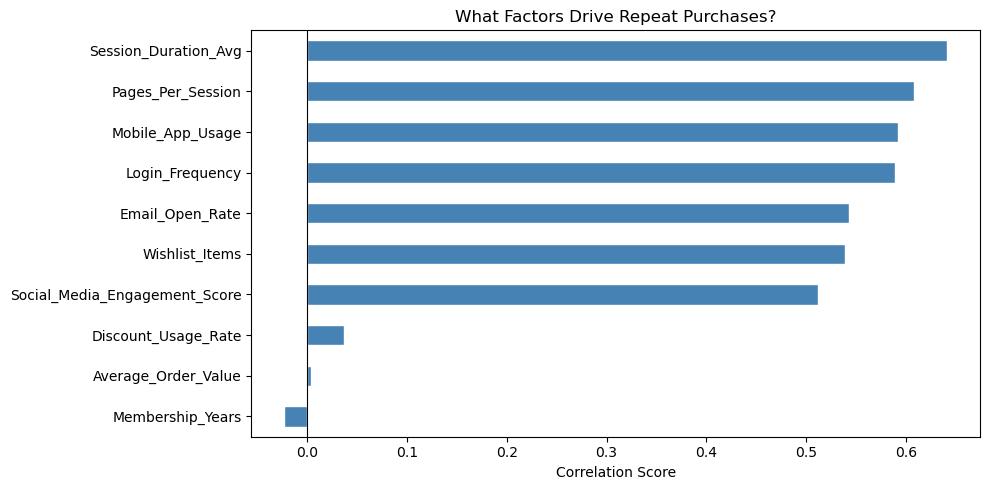

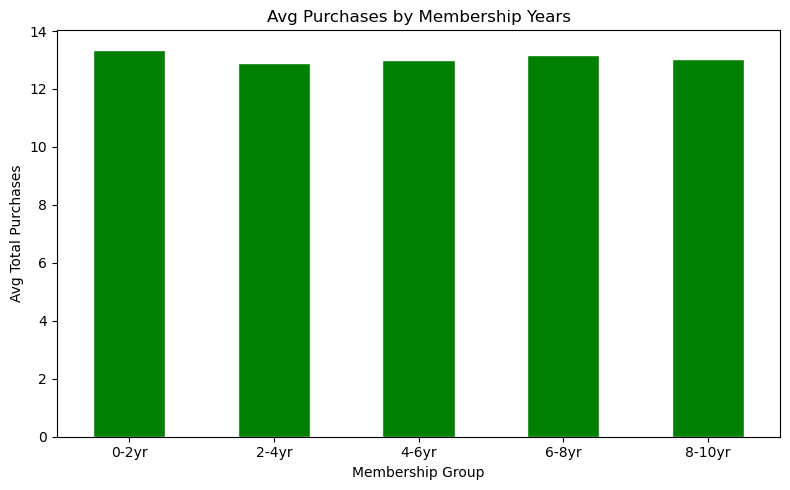

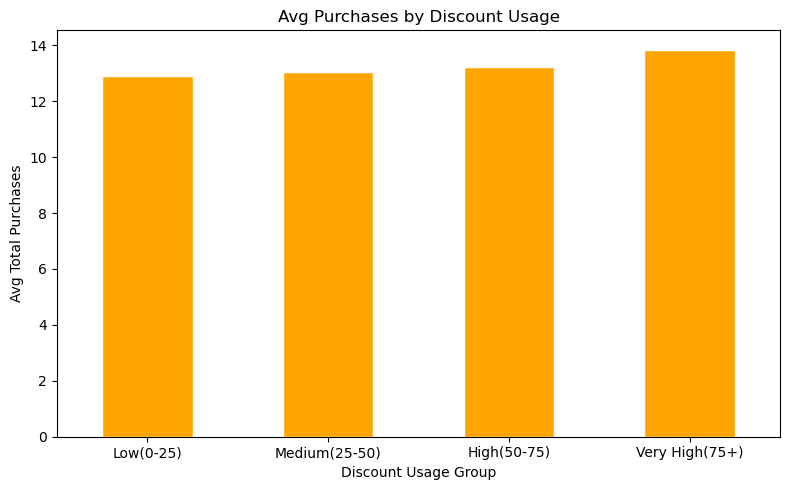

In [74]:
# ---- 1. Correlation — what is related to Total Purchases ----
print("Correlation with Total Purchases:")
cols = ['Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
        'Membership_Years', 'Discount_Usage_Rate', 'Email_Open_Rate',
        'Mobile_App_Usage', 'Average_Order_Value', 'Wishlist_Items',
        'Social_Media_Engagement_Score']

corr = df[cols + ['Total_Purchases']].corr()['Total_Purchases'].drop('Total_Purchases')
print(corr.sort_values(ascending=False).round(3))

# ---- 2. Membership Years vs Repeat Purchases ----
print("\nAvg Purchases by Membership Group:")
df['Membership_Group'] = pd.cut(df['Membership_Years'],
                                 bins=[0, 2, 4, 6, 8, 10],
                                 labels=['0-2yr','2-4yr','4-6yr','6-8yr','8-10yr'])

mem_pur = df.groupby('Membership_Group', observed=True)['Total_Purchases'].mean()
print(mem_pur.round(2))

# ---- 3. Discount Usage vs Repeat Purchases ----
print("\nAvg Purchases by Discount Usage Group:")
df['Discount_Group'] = pd.cut(df['Discount_Usage_Rate'],
                               bins=[0, 25, 50, 75, 100],
                               labels=['Low(0-25)','Medium(25-50)',
                                       'High(50-75)','Very High(75+)'])

disc_pur = df.groupby('Discount_Group', observed=True)['Total_Purchases'].mean()
print(disc_pur.round(2))

# ---- 4. Wishlist Items vs Repeat Purchases ----
print("\nAvg Purchases by Wishlist Group:")
df['Wishlist_Group'] = pd.cut(df['Wishlist_Items'],
                               bins=[-1, 2, 5, 10, 30],
                               labels=['Low(0-2)','Medium(2-5)',
                                       'High(5-10)','Very High(10+)'])

wish_pur = df.groupby('Wishlist_Group', observed=True)['Total_Purchases'].mean()
print(wish_pur.round(2))

# ---- 5. Bar Chart — Correlation with Total Purchases ----
plt.figure(figsize=(10, 5))
corr.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('What Factors Drive Repeat Purchases?')
plt.xlabel('Correlation Score')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# ---- 6. Bar Chart — Membership Years vs Purchases ----
plt.figure(figsize=(8, 5))
mem_pur.plot(kind='bar', color='green', edgecolor='white')
plt.title('Avg Purchases by Membership Years')
plt.xlabel('Membership Group')
plt.ylabel('Avg Total Purchases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- 7. Bar Chart — Discount Usage vs Purchases ----
plt.figure(figsize=(8, 5))
disc_pur.plot(kind='bar', color='orange', edgecolor='white')
plt.title('Avg Purchases by Discount Usage')
plt.xlabel('Discount Usage Group')
plt.ylabel('Avg Total Purchases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### ❓Question 8 — Which Customers Respond Best to Discounts?

Avg Purchases & Revenue by Discount Usage:
                Avg_Purchases  Avg_Revenue  Avg_Order_Value  Churn_Rate
Discount_Group                                                         
Low(0-25)               12.89      1438.29           123.68        35.0
Medium(25-50)           13.04      1439.13           122.83        28.0
High(50-75)             13.23      1446.28           123.14        26.0
Very High(75+)          13.84      1432.75           123.15        26.0

Avg Discount Usage by Gender:
Gender
Male      41.98
Other     41.97
Female    41.77
Name: Discount_Usage_Rate, dtype: float64

Avg Discount Usage by Country:
Country
Japan        42.34
France       42.09
USA          42.01
Australia    41.96
Germany      41.93
Canada       41.67
India        41.53
UK           41.51
Name: Discount_Usage_Rate, dtype: float64

Avg Purchases by Age Group (Discount Users):
Age_Group
18-25    13.46
25-35    13.26
35-45    13.39
45-55    13.58
55+      13.20
Name: Total_Purchases, dtype: fl

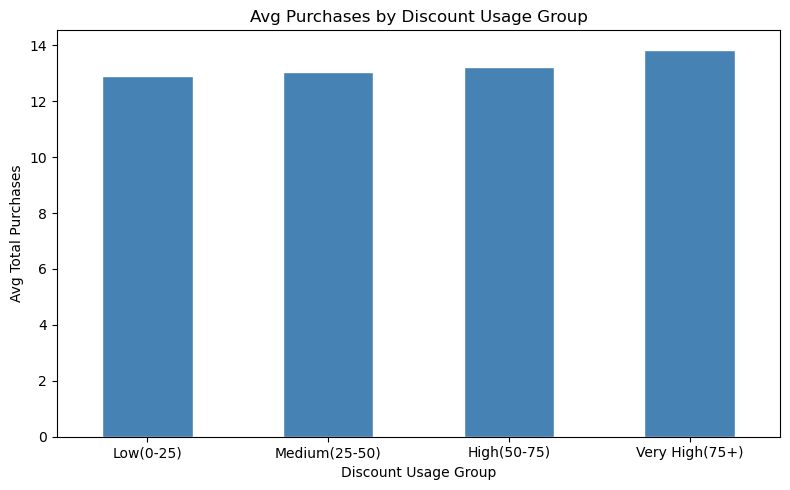

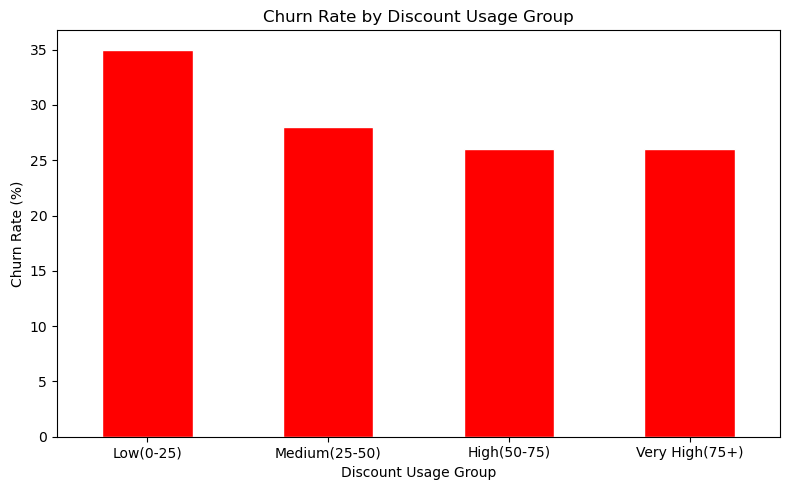

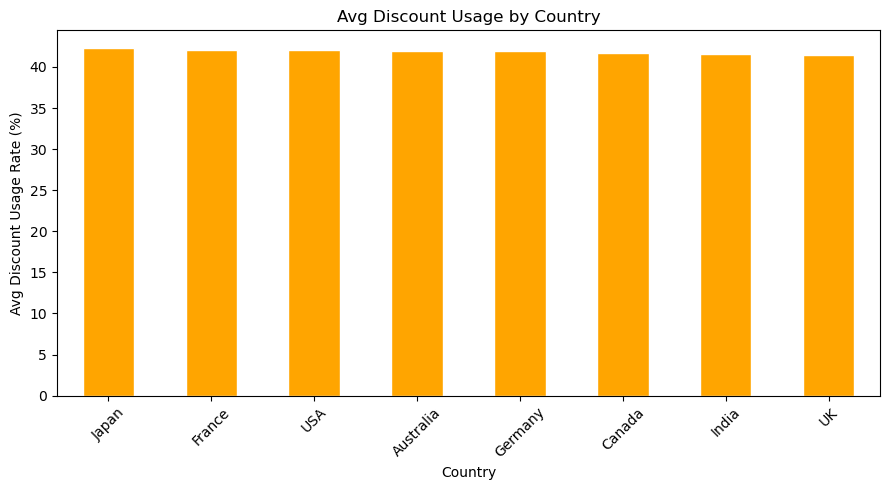

In [75]:
# ---- 1. Segment customers by Discount Usage ----
df['Discount_Group'] = pd.cut(df['Discount_Usage_Rate'],
                               bins=[0, 25, 50, 75, 100],
                               labels=['Low(0-25)', 'Medium(25-50)',
                                       'High(50-75)', 'Very High(75+)'])

# ---- 2. Avg Purchases & Revenue by Discount Group ----
print("Avg Purchases & Revenue by Discount Usage:")
disc_summary = df.groupby('Discount_Group', observed=True).agg(
    Avg_Purchases   = ('Total_Purchases', 'mean'),
    Avg_Revenue     = ('Lifetime_Value', 'mean'),
    Avg_Order_Value = ('Average_Order_Value', 'mean'),
    Churn_Rate      = ('Churned', 'mean')
).round(2)
disc_summary['Churn_Rate'] = (disc_summary['Churn_Rate'] * 100).round(2)
print(disc_summary)

# ---- 3. Discount Usage by Gender ----
print("\nAvg Discount Usage by Gender:")
gender_disc = df.groupby('Gender')['Discount_Usage_Rate'].mean().sort_values(ascending=False)
print(gender_disc.round(2))

# ---- 4. Discount Usage by Country ----
print("\nAvg Discount Usage by Country:")
country_disc = df.groupby('Country')['Discount_Usage_Rate'].mean().sort_values(ascending=False)
print(country_disc.round(2))

# ---- 5. Discount Usage by Age Group ----
print("\nAvg Purchases by Age Group (Discount Users):")
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0, 25, 35, 45, 55, 100],
                          labels=['18-25', '25-35', '35-45', '45-55', '55+'])

# Filter only high discount users
high_disc = df[df['Discount_Usage_Rate'] > 50]
age_disc = high_disc.groupby('Age_Group', observed=True)['Total_Purchases'].mean()
print(age_disc.round(2))

# ---- 6. Bar Chart — Avg Purchases by Discount Group ----
plt.figure(figsize=(8, 5))
disc_summary['Avg_Purchases'].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Avg Purchases by Discount Usage Group')
plt.xlabel('Discount Usage Group')
plt.ylabel('Avg Total Purchases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- 7. Bar Chart — Churn Rate by Discount Group ----
plt.figure(figsize=(8, 5))
disc_summary['Churn_Rate'].plot(kind='bar', color='red', edgecolor='white')
plt.title('Churn Rate by Discount Usage Group')
plt.xlabel('Discount Usage Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- 8. Bar Chart — Discount Usage by Country ----
plt.figure(figsize=(9, 5))
country_disc.plot(kind='bar', color='orange', edgecolor='white')
plt.title('Avg Discount Usage by Country')
plt.xlabel('Country')
plt.ylabel('Avg Discount Usage Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ❓Question 9 — Which Customer Segment is Most Profitable?

Customer Count by Segment:
Segment
Loyal        16871
Lost         14450
At Risk       7443
Regular       6592
Champions     4644
Name: count, dtype: int64

Profitability Summary by Segment:
           Total_Customers  Avg_Revenue  Total_Revenue  Avg_Purchases  \
Segment                                                                 
Champions             4644      2519.34    11699809.40          24.76   
Loyal                16871      1546.73    26094898.15          14.77   
Lost                 14450      1425.42    20597365.76          11.35   
Regular               6592      1007.59     6642004.80           9.29   
At Risk               7443       940.11     6997236.49           8.92   

           Avg_Order_Value  
Segment                     
Champions           120.77  
Loyal               118.24  
Lost                134.76  
Regular             118.45  
At Risk             117.15  


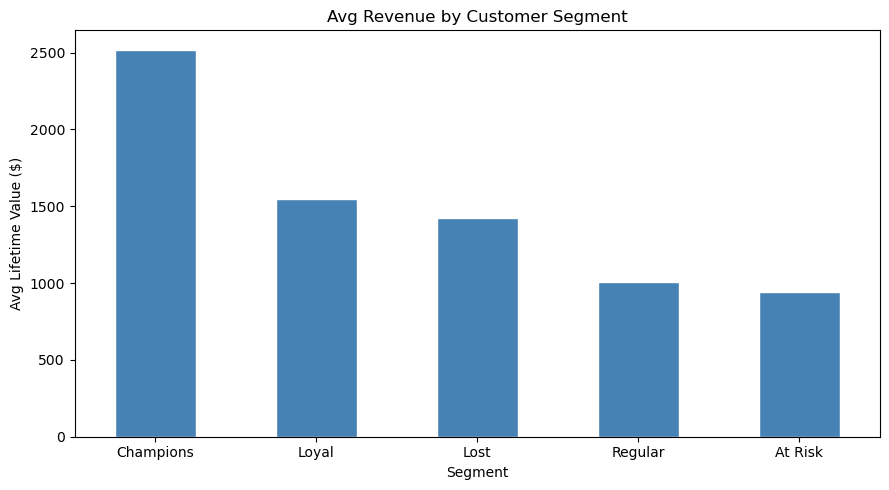

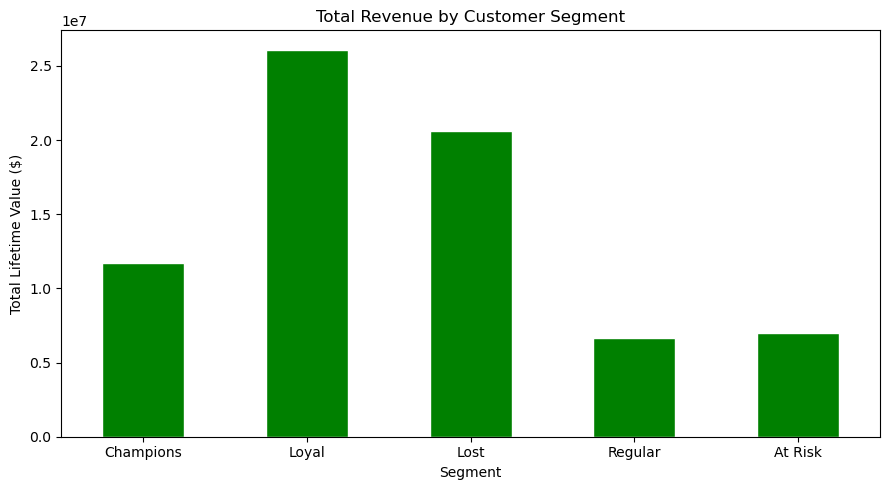

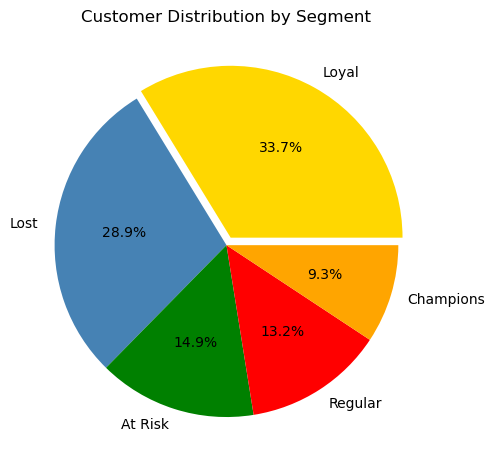

In [76]:
# ---- 1. Create Customer Segments based on behavior ----
# We use 3 rules to define segments:
# Champions   — high purchases + high login + low churn risk
# Loyal       — medium purchases + medium login
# At Risk     — low login + high cart abandonment
# Lost        — already churned

def assign_segment(row):
    if row['Churned'] == 1:
        return 'Lost'
    elif row['Total_Purchases'] >= 20 and row['Login_Frequency'] >= 15:
        return 'Champions'
    elif row['Total_Purchases'] >= 10 and row['Login_Frequency'] >= 8:
        return 'Loyal'
    elif row['Cart_Abandonment_Rate'] > 70 or row['Login_Frequency'] < 5:
        return 'At Risk'
    else:
        return 'Regular'

df['Segment'] = df.apply(assign_segment, axis=1)

# ---- 2. Count per Segment ----
print("Customer Count by Segment:")
print(df['Segment'].value_counts())

# ---- 3. Profitability by Segment ----
print("\nProfitability Summary by Segment:")
seg_summary = df.groupby('Segment').agg(
    Total_Customers = ('Lifetime_Value', 'count'),
    Avg_Revenue     = ('Lifetime_Value', 'mean'),
    Total_Revenue   = ('Lifetime_Value', 'sum'),
    Avg_Purchases   = ('Total_Purchases', 'mean'),
    Avg_Order_Value = ('Average_Order_Value', 'mean')
).round(2)
seg_summary = seg_summary.sort_values('Avg_Revenue', ascending=False)
print(seg_summary)

# ---- 4. Bar Chart — Avg Revenue by Segment ----
plt.figure(figsize=(9, 5))
seg_summary['Avg_Revenue'].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Avg Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Avg Lifetime Value ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- 5. Bar Chart — Total Revenue by Segment ----
plt.figure(figsize=(9, 5))
seg_summary['Total_Revenue'].plot(kind='bar', color='green', edgecolor='white')
plt.title('Total Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Lifetime Value ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- 6. Pie Chart — Customer Count by Segment ----
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    colors=['gold','steelblue','green','red','orange'],
    explode=(0.05, 0, 0, 0, 0))
plt.title('Customer Distribution by Segment')
plt.ylabel('')
plt.tight_layout()
plt.show()

### ❓Question 10 — What Behaviors Indicate Future Churn?

Correlation of All Features with Churn:
Customer_Service_Calls           0.290
Cart_Abandonment_Rate            0.279
Days_Since_Last_Purchase         0.148
Returns_Rate                     0.051
Average_Order_Value              0.042
Membership_Years                -0.001
Lifetime_Value                  -0.011
Discount_Usage_Rate             -0.074
Total_Purchases                 -0.160
Social_Media_Engagement_Score   -0.180
Wishlist_Items                  -0.190
Login_Frequency                 -0.204
Mobile_App_Usage                -0.211
Email_Open_Rate                 -0.216
Session_Duration_Avg            -0.220
Pages_Per_Session               -0.225
Name: Churned, dtype: float64

Churn Risk Score Distribution:
Churn_Risk_Score
0    22464
1    12827
2     7036
3     4247
4     2290
5      894
6      231
7       11
Name: count, dtype: int64

Actual Churn Rate by Risk Score:
Churn_Risk_Score
0    17.83
1    21.31
2    34.57
3    56.98
4    80.22
5    89.71
6    91.34
7    90.91
Name

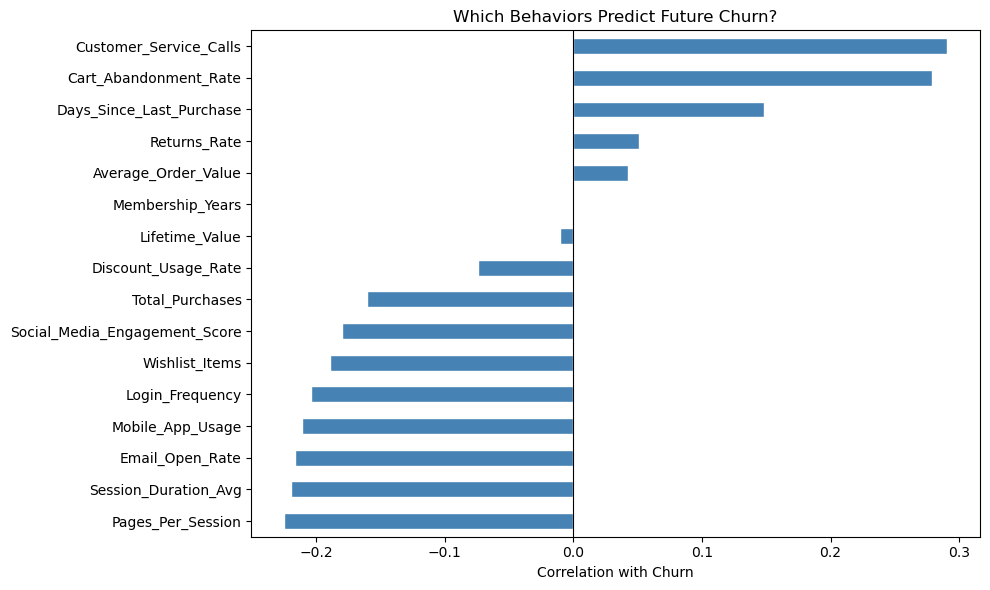

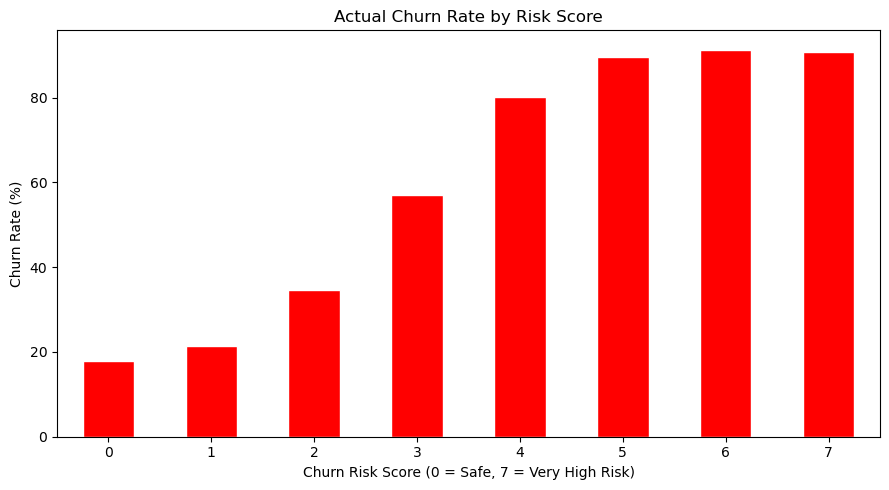

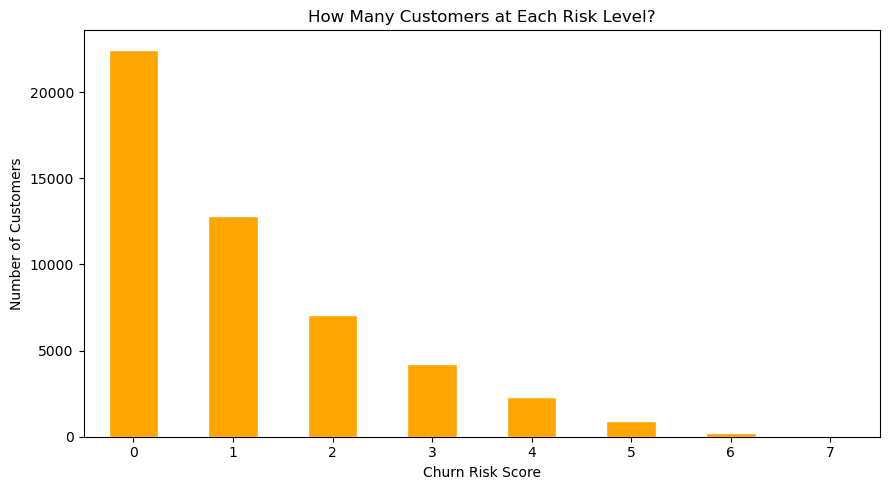

In [78]:
# ---- 1. Correlation — all features vs Churned ----
print("Correlation of All Features with Churn:")
cols = ['Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
        'Cart_Abandonment_Rate', 'Customer_Service_Calls', 'Email_Open_Rate',
        'Mobile_App_Usage', 'Total_Purchases', 'Average_Order_Value',
        'Discount_Usage_Rate', 'Returns_Rate', 'Membership_Years',
        'Social_Media_Engagement_Score', 'Days_Since_Last_Purchase',
        'Wishlist_Items', 'Lifetime_Value']

corr = df[cols + ['Churned']].corr()['Churned'].drop('Churned')
print(corr.sort_values(ascending=False).round(3))

# ---- 2. Define Churn Risk Score for each customer ----
# Higher score = higher chance of churning
# We add 1 point for each warning sign

df['Churn_Risk_Score'] = 0

df['Churn_Risk_Score'] += (df['Cart_Abandonment_Rate'] > 70).astype(int)
df['Churn_Risk_Score'] += (df['Customer_Service_Calls'] > 8).astype(int)
df['Churn_Risk_Score'] += (df['Login_Frequency'] < 5).astype(int)
df['Churn_Risk_Score'] += (df['Email_Open_Rate'] < 10).astype(int)
df['Churn_Risk_Score'] += (df['Session_Duration_Avg'] < 15).astype(int)
df['Churn_Risk_Score'] += (df['Days_Since_Last_Purchase'] > 60).astype(int)
df['Churn_Risk_Score'] += (df['Total_Purchases'] < 5).astype(int)

print("\nChurn Risk Score Distribution:")
print(df['Churn_Risk_Score'].value_counts().sort_index())

# ---- 3. How many actually churned per risk score ----
print("\nActual Churn Rate by Risk Score:")
risk_churn = df.groupby('Churn_Risk_Score')['Churned'].mean() * 100
print(risk_churn.round(2))

# ---- 4. High Risk Customers (score 4 or more) ----
high_risk = df[df['Churn_Risk_Score'] >= 4]
print(f"\nHigh Risk Customers (score 4+) : {len(high_risk)}")
print(f"Already Churned from High Risk : {high_risk['Churned'].sum()}")
print(f"Still Active High Risk         : {len(high_risk) - high_risk['Churned'].sum()}")

# ---- 5. Bar Chart — Correlation with Churn ----
plt.figure(figsize=(10, 6))
corr.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Which Behaviors Predict Future Churn?')
plt.xlabel('Correlation with Churn')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# ---- 6. Bar Chart — Churn Rate by Risk Score ----
plt.figure(figsize=(9, 5))
risk_churn.plot(kind='bar', color='red', edgecolor='white')
plt.title('Actual Churn Rate by Risk Score')
plt.xlabel('Churn Risk Score (0 = Safe, 7 = Very High Risk)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- 7. Bar Chart — Risk Score Distribution ----
plt.figure(figsize=(9, 5))
df['Churn_Risk_Score'].value_counts().sort_index().plot(
    kind='bar', color='orange', edgecolor='white')
plt.title('How Many Customers at Each Risk Level?')
plt.xlabel('Churn Risk Score')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()